In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [11]:
# Loading the dataframe
df = pd.read_csv("compiled_WHO_GLASS_2022.csv")

Inspecting the dataframe

In [12]:

df.head()

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
0,AFG,Afghanistan,Eastern Mediterranean Region,2019,URINE,Escherichia coli,Cefotaxime,28,12,8,66.666667
1,AFG,Afghanistan,Eastern Mediterranean Region,2019,URINE,Escherichia coli,Ceftazidime,28,14,3,21.428571
2,AFG,Afghanistan,Eastern Mediterranean Region,2019,URINE,Escherichia coli,Ceftriaxone,28,27,19,70.370370
3,AFG,Afghanistan,Eastern Mediterranean Region,2019,URINE,Escherichia coli,Trimethoprim/sulfamethoxazole,28,16,11,68.750000
4,ARE,United Arab Emirates,Eastern Mediterranean Region,2017,BLOOD,Acinetobacter,Amikacin,1982,29,6,20.689655


In [6]:
df.tail()

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
6397,ZMB,Zambia,African Region,2019,URINE,Escherichia coli,Imipenem,581,16,1,6.250000
6398,ZMB,Zambia,African Region,2019,URINE,Escherichia coli,Trimethoprim/sulfamethoxazole,581,22,16,72.727273
6399,ZMB,Zambia,African Region,2019,URINE,Klebsiella pneumoniae,Cefotaxime,581,14,5,35.714286
6400,ZMB,Zambia,African Region,2019,URINE,Klebsiella pneumoniae,Ciprofloxacin,581,31,19,61.290323
6401,ZMB,Zambia,African Region,2019,URINE,Klebsiella pneumoniae,Imipenem,581,20,0,0.000000


In [7]:
df.shape

(6402, 11)

In [8]:
df.columns

Index(['Iso3', 'CountryTerritoryArea', 'WHORegionName', 'Year', 'Specimen',
       'PathogenName', 'AbTargets', 'TotalSpecimenIsolates',
       'InterpretableAST', 'Resistant', 'PercentResistant'],
      dtype='str')

In [9]:
df.columns.tolist()

['Iso3',
 'CountryTerritoryArea',
 'WHORegionName',
 'Year',
 'Specimen',
 'PathogenName',
 'AbTargets',
 'TotalSpecimenIsolates',
 'InterpretableAST',
 'Resistant',
 'PercentResistant']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6402 entries, 0 to 6401
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Iso3                   6402 non-null   str    
 1   CountryTerritoryArea   6402 non-null   str    
 2   WHORegionName          6402 non-null   str    
 3   Year                   6402 non-null   int64  
 4   Specimen               6402 non-null   str    
 5   PathogenName           6402 non-null   str    
 6   AbTargets              6402 non-null   str    
 7   TotalSpecimenIsolates  6402 non-null   int64  
 8   InterpretableAST       6402 non-null   int64  
 9   Resistant              6402 non-null   int64  
 10  PercentResistant       6402 non-null   float64
dtypes: float64(1), int64(4), str(6)
memory usage: 550.3 KB


In [13]:
df.dtypes

Iso3                         str
CountryTerritoryArea         str
WHORegionName                str
Year                       int64
Specimen                     str
PathogenName                 str
AbTargets                    str
TotalSpecimenIsolates      int64
InterpretableAST           int64
Resistant                  int64
PercentResistant         float64
dtype: object

In [14]:
df.describe()

,Year,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
count,6402.000000,6402.000000,6402.000000,6402.000000,6402.000000
mean,2018.650734,30426.146517,7428.187598,1313.643705,28.938462
std,0.962266,108848.444303,41540.557011,11172.395011,27.923029
min,2017.000000,12.000000,10.000000,0.000000,0.000000
25%,2018.000000,841.000000,86.000000,7.000000,3.201129
50%,2019.000000,3519.000000,355.000000,52.000000,20.379171
75%,2019.000000,10215.000000,1711.000000,331.000000,50.000000
max,2020.000000,880701.000000,822931.000000,380972.000000,100.000000


In [15]:
df.describe(include="all")

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
count,6402,6402,6402,6402.000000,6402,6402,6402,6402.000000,6402.000000,6402.000000,6402.000000
unique,71,71,6,NaN,4,8,25,NaN,NaN,NaN,NaN
top,ARE,United Arab Emirates,European Region,NaN,BLOOD,Escherichia coli,Ciprofloxacin,NaN,NaN,NaN,NaN
freq,312,312,1845,NaN,3853,2353,707,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018.650734,NaN,NaN,NaN,30426.146517,7428.187598,1313.643705,28.938462
std,NaN,NaN,NaN,0.962266,NaN,NaN,NaN,108848.444303,41540.557011,11172.395011,27.923029
min,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,12.000000,10.000000,0.000000,0.000000
25%,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,841.000000,86.000000,7.000000,3.201129
50%,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,3519.000000,355.000000,52.000000,20.379171
75%,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,10215.000000,1711.000000,331.000000,50.000000


Missing data functions


In [17]:
df.isnull().sum()

Iso3                     0
CountryTerritoryArea     0
WHORegionName            0
Year                     0
Specimen                 0
PathogenName             0
AbTargets                0
TotalSpecimenIsolates    0
InterpretableAST         0
Resistant                0
PercentResistant         0
dtype: int64

In [18]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [19]:
#selecting columns
df[["Year", "PathogenName", "Resistant"]]

,Year,PathogenName,Resistant
0,2019,Escherichia coli,8
1,2019,Escherichia coli,3
2,2019,Escherichia coli,19
3,2019,Escherichia coli,11
4,2017,Acinetobacter,6
...,...,...,...
6397,2019,Escherichia coli,1
6398,2019,Escherichia coli,16
6399,2019,Klebsiella pneumoniae,5
6400,2019,Klebsiella pneumoniae,19


In [21]:
# clean all cleans
df.columns = df.columns.str.strip()

In [23]:
df.columns.tolist()

['Iso3',
 'CountryTerritoryArea',
 'WHORegionName',
 'Year',
 'Specimen',
 'PathogenName',
 'AbTargets',
 'TotalSpecimenIsolates',
 'InterpretableAST',
 'Resistant',
 'PercentResistant']

In [37]:
#Clean specimen names
df["Specimen"] = (df["Specimen"].astype("string").str.strip() .str.upper().str.title())



In [40]:
# Clean pathogen names

df["PathogenName"] = (df["PathogenName"].astype("string").str.strip().str.lower().str.capitalize())

In [26]:
# Clean antibiotic names
df["AbTargets"] = (df["AbTargets"].astype("string").str.strip())

In [39]:
# Clean country names
df["CountryTerritoryArea"] = ( df["CountryTerritoryArea"].astype("string") .str.strip().str.title())

In [43]:
# Examine countries
df["CountryTerritoryArea"].value_counts()

CountryTerritoryArea
United Arab Emirates    312
Malaysia                308
Philippines             304
Saudi Arabia            298
Switzerland             292
                       ... 
Sudan                    11
Yemen                    10
Syria                     7
Peru                      6
Afghanistan               4
Name: count, Length: 71, dtype: Int64

In [42]:
# Examine specimens
df["Specimen"].value_counts()

Specimen
Blood      3853
Urine      1900
Stool       473
Genital     176
Name: count, dtype: Int64

In [41]:
# Examine pathogens
df["PathogenName"].value_counts()

PathogenName
Escherichia coli            2353
Klebsiella pneumoniae       1945
Salmonella                   758
Acinetobacter                561
Streptococcus pneumoniae     253
Staphylococcus aureus        236
Neisseria gonorrhoeae        176
Shigella                     120
Name: count, dtype: Int64

In [32]:
# Examine antibiotics
df["AbTargets"].value_counts()

AbTargets
Ciprofloxacin                    707
Imipenem                         644
Ceftriaxone                      616
Meropenem                        600
Ceftazidime                      559
Cefotaxime                       546
Trimethoprim/sulfamethoxazole    369
Ertapenem                        358
Cefepime                         334
Levofloxacin                     285
Colistin                         271
Ampicillin                       196
Tinidazole                       152
Meticillin                       144
Gentamicin                       113
Amikacin                         107
Oxacillin                         78
Benzylpenicillin                  71
Doripenem                         59
Cefoxitin                         50
Minocycline                       34
Azithromycin                      34
Cefixime                          27
Spectinomycin                     24
Tigecycline                       24
Name: count, dtype: Int64

In [44]:
# unique categories
df["Specimen"].unique()


<StringArray>
['Urine', 'Blood', 'Stool', 'Genital']
Length: 4, dtype: string

In [51]:
# to Identify numeric columns
numeric_columns = [
    "Year", "TotalSpecimenIsolates", "InterpretableAST", "Resistant", "PercentResistant"]
numeric_columns

['Year',
 'TotalSpecimenIsolates',
 'InterpretableAST',
 'Resistant',
 'PercentResistant']

In [50]:
print(df.columns.tolist())

['Iso3', 'CountryTerritoryArea', 'WHORegionName', 'Year', 'Specimen', 'PathogenName', 'AbTargets', 'TotalSpecimenIsolates', 'InterpretableAST', 'Resistant', 'PercentResistant']


In [52]:
# to Convert them to numeric
for col in numeric_columns: df[col] = pd.to_numeric( df[col], errors="coerce" )

In [56]:
# Checking for minimum values
df[numeric_columns].min()



Year                     2017.0
TotalSpecimenIsolates      12.0
InterpretableAST           10.0
Resistant                   0.0
PercentResistant            0.0
dtype: float64

In [55]:
# Checking for maximum values
df[numeric_columns].max()

Year                       2020.0
TotalSpecimenIsolates    880701.0
InterpretableAST         822931.0
Resistant                380972.0
PercentResistant            100.0
dtype: float64

In [57]:
# Checking for negative resistant counts
df[df["Resistant"] < 0]


,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant


In [58]:
#Checking for resistant > interpretable AST
df[df["Resistant"] > df["InterpretableAST"]]

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant


In [66]:
# Checking fo interpretable AST > isolates
df[df["InterpretableAST"] > df["TotalSpecimenIsolates"]]

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant,CalculatedPercentResistant,PercentDifference


In [67]:
# Checking fo isolates > total specimens
# Interpretable AST should not exceed total isolates
df[df["TotalSpecimenIsolates"] > df["InterpretableAST"]]

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant,CalculatedPercentResistant,PercentDifference
0,AFG,Afghanistan,Eastern Mediterranean Region,2019,Urine,Escherichia coli,Cefotaxime,28,12,8,66.666667,66.666667,4.263256e-14
1,AFG,Afghanistan,Eastern Mediterranean Region,2019,Urine,Escherichia coli,Ceftazidime,28,14,3,21.428571,21.428571,-2.842171e-14
2,AFG,Afghanistan,Eastern Mediterranean Region,2019,Urine,Escherichia coli,Ceftriaxone,28,27,19,70.370370,70.370370,2.842171e-14
3,AFG,Afghanistan,Eastern Mediterranean Region,2019,Urine,Escherichia coli,Trimethoprim/sulfamethoxazole,28,16,11,68.750000,68.750000,0.000000e+00
4,ARE,United Arab Emirates,Eastern Mediterranean Region,2017,Blood,Acinetobacter,Amikacin,1982,29,6,20.689655,20.689655,7.105427e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6397,ZMB,Zambia,African Region,2019,Urine,Escherichia coli,Imipenem,581,16,1,6.250000,6.250000,0.000000e+00
6398,ZMB,Zambia,African Region,2019,Urine,Escherichia coli,Trimethoprim/sulfamethoxazole,581,22,16,72.727273,72.727273,-2.842171e-14
6399,ZMB,Zambia,African Region,2019,Urine,Klebsiella pneumoniae,Cefotaxime,581,14,5,35.714286,35.714286,-1.421085e-14
6400,ZMB,Zambia,African Region,2019,Urine,Klebsiella pneumoniae,Ciprofloxacin,581,31,19,61.290323,61.290323,4.263256e-14


In [61]:
# Calculating for resistance yourself
df["CalculatedPercentResistant"] = np.where( df["InterpretableAST"] > 0, df["Resistant"] / df["InterpretableAST"] * 100,
    np.nan)

In [62]:
# Comparing supplied and calculated percentages
df [[ "PercentResistant", "CalculatedPercentResistant" ]].head(10)

,PercentResistant,CalculatedPercentResistant
0,66.666667,66.666667
1,21.428571,21.428571
2,70.370370,70.370370
3,68.750000,68.750000
4,20.689655,20.689655
5,8.333333,8.333333
6,40.298507,40.298507
7,44.615385,44.615385
8,42.647059,42.647059
9,20.000000,20.000000


In [63]:
# Calculate the difference
df["PercentDifference"] = ( df["PercentResistant"] -df["CalculatedPercentResistant"])

In [72]:
# to Flag potentially invalid records
df["valid_record"] = ((df["TotalSpecimenIsolates"] >= 0) & (df["InterpretableAST"] >= 0) & (df["Resistant"] >= 0) &
    (df["Resistant"] <= df["InterpretableAST"]) &(df["InterpretableAST"] <= df["TotalSpecimenIsolates"]))

In [73]:
# to Count valid/invalid records
df["valid_record"].value_counts()

valid_record
True    6402
Name: count, dtype: int64

In [74]:
# to Calculate overall resistance
overall_resistance = ( df["Resistant"].sum() /df["InterpretableAST"].sum()) * 100
overall_resistance

np.float64(17.68457901510237)

In [116]:
# Group by antibiotic
amr_antibiotic = (df.groupby("AbTargets") .agg( resistant=("Resistant", "sum"),
          interpretable=("InterpretableAST", "sum")))

In [117]:
# Calculate resistance percentage
amr_antibiotic["resistance_percent"] = (amr_antibiotic["resistant"] /amr_antibiotic["interpretable"] * 100)

In [118]:
# Sort results
amr_antibiotic.sort_values( "resistance_percent",ascending=False)

,resistant,interpretable,resistance_percent
AbTargets,,,
Gentamicin,21492,40118,53.571963
Ampicillin,2754016,5614475,49.052066
Amikacin,19070,43091,44.255181
Trimethoprim/sulfamethoxazole,766514,2818403,27.196749
Levofloxacin,786296,3082407,25.509156
Oxacillin,20682,87912,23.525799
Cefoxitin,11896,50874,23.383261
Meticillin,81329,364428,22.316891
Cefotaxime,707875,3637283,19.461642


In [119]:
# Resistance by pathogen
amr_pathogen = (df.groupby("PathogenName") .agg  (resistant=("Resistant", "sum"),
          interpretable=("InterpretableAST", "sum") ))

amr_pathogen["resistance_percent"] = (amr_pathogen["resistant"] / amr_pathogen["interpretable"] * 100)

In [120]:
#Resistance by WHO region
amr_region = (df.groupby("WHORegionName") .agg(  resistant=("Resistant", "sum"), interpretable=("InterpretableAST", "sum")))

amr_region["resistance_percent"] = (amr_region["resistant"] /amr_region["interpretable"] * 100)

In [121]:
# Resistance by year
amr_year = ( df.groupby("Year") .agg( resistant=("Resistant", "sum"), interpretable=("InterpretableAST", "sum")))

amr_year["resistance_percent"] = (amr_year["resistant"] /amr_year["interpretable"] * 100)

In [115]:
# Pathogen × antibiotic
amr_pathogen_antibiotic = (df.groupby(["PathogenName", "AbTargets"])).agg(  resistant=("Resistant", "sum"), 
interpretable=("InterpretableAST", "sum"))

amr_pathogen_antibiotic["resistance_percent"] = (amr_pathogen_antibiotic["resistant"] /
    amr_pathogen_antibiotic["interpretable"] * 100)

In [ ]:
Visualization

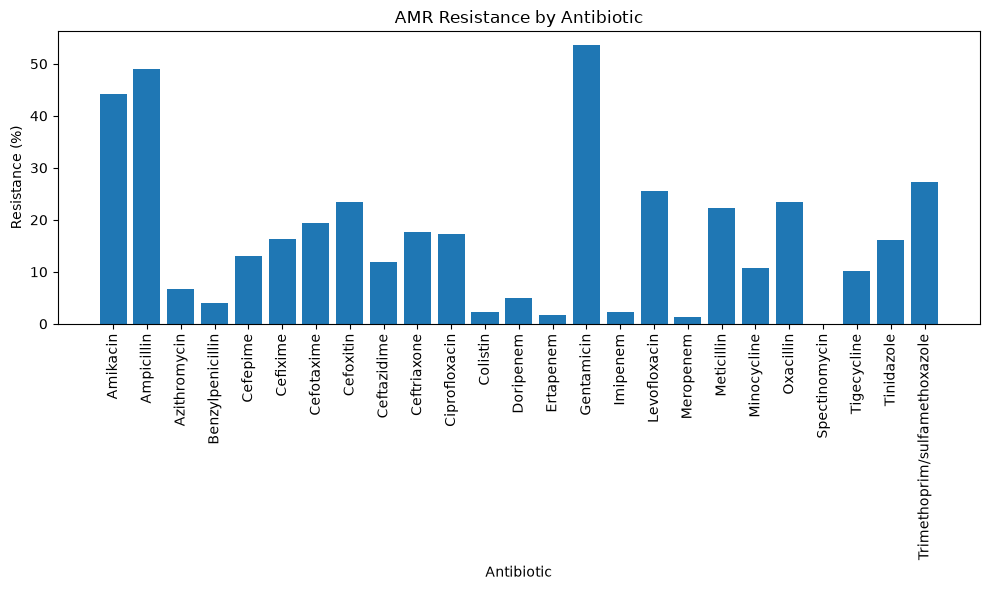

In [111]:

# Antibiotic resistance bar chart
plt.figure(figsize=(10, 6))

plt.bar(amr_antibiotic.index, amr_antibiotic["resistance_percent"])

plt.xlabel("Antibiotic")
plt.ylabel("Resistance (%)")
plt.title("AMR Resistance by Antibiotic")

plt.xticks(rotation=90)
plt.tight_layout()
# Save figure
plt.savefig("AMR_resistance_by_antibiotic.png", dpi=300, bbox_inches="tight")

plt.show()

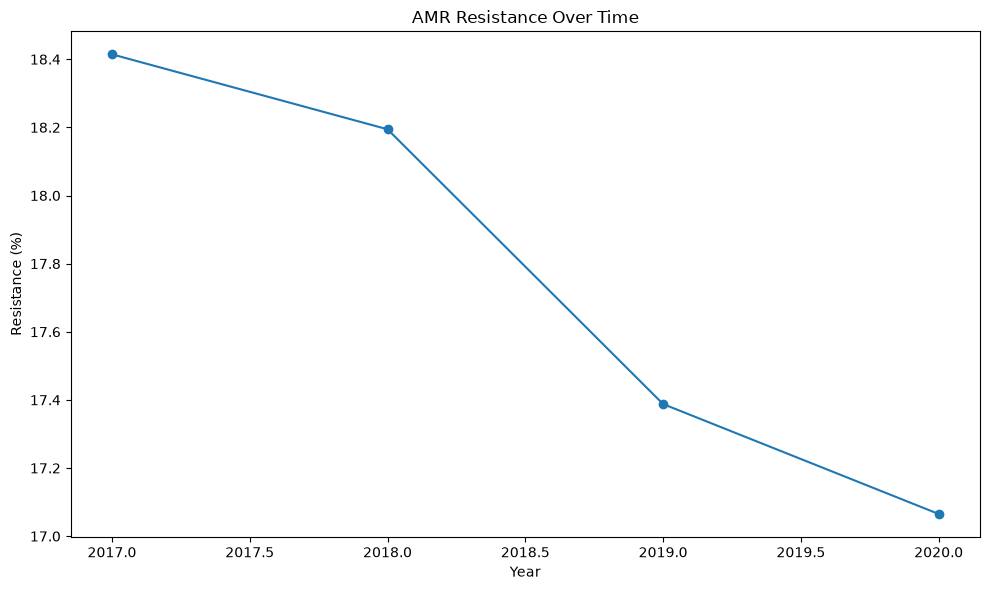

In [109]:
# Resistance trend
plt.figure(figsize=(10, 6))

plt.plot(amr_year.index, amr_year["resistance_percent"], marker="o")
plt.xlabel("Year")
plt.ylabel("Resistance (%)")
plt.title("AMR Resistance Over Time")

plt.tight_layout()
# Save figure
plt.savefig("AMR_resistance Over Time.png", dpi=300, bbox_inches="tight")
plt.show()

In [110]:
#Heatmap

##I would first reshape:

heatmap_data = (amr_pathogen_antibiotic[  "resistance_percent"].unstack())



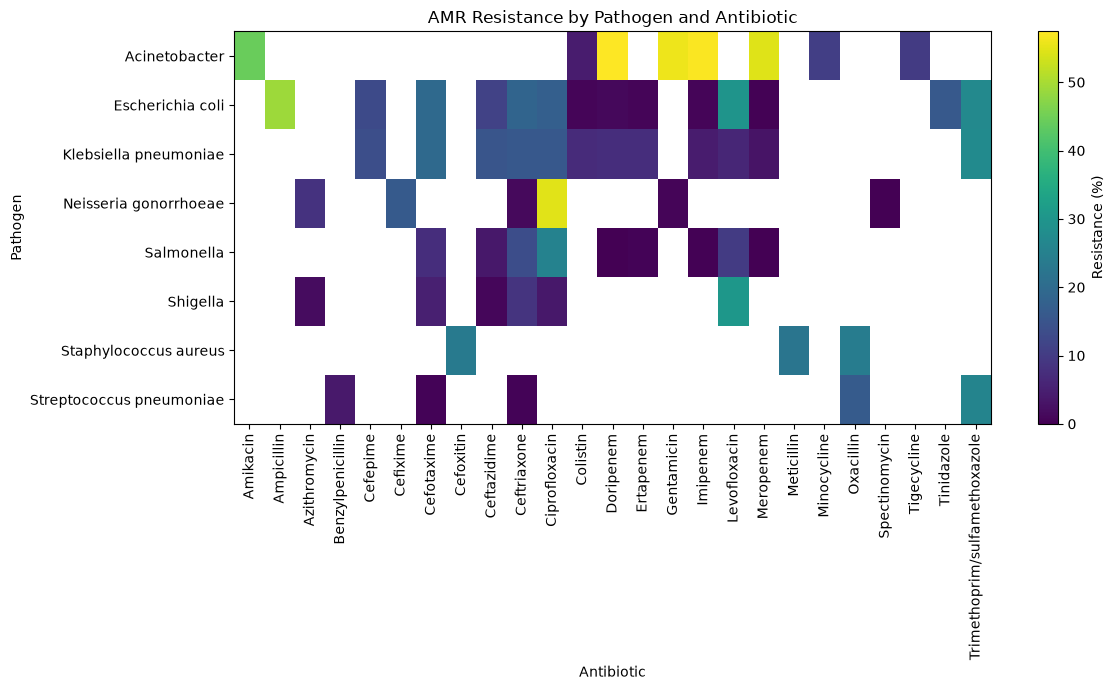

In [107]:

plt.figure(figsize=(12, 7))

plt.imshow( heatmap_data, aspect="auto")

plt.colorbar(label="Resistance (%)")

plt.xticks( range(len(heatmap_data.columns)),
    heatmap_data.columns, rotation=90)

plt.yticks( range(len(heatmap_data.index)), heatmap_data.index)

plt.xlabel("Antibiotic")
plt.ylabel("Pathogen")
plt.title("AMR Resistance by Pathogen and Antibiotic")

plt.tight_layout()
# Save figure
plt.savefig("AMR_resistance by Pathogen and Antibiotic.png", dpi=300, bbox_inches="tight")
plt.show()

In [106]:
# Advanced statistics: Wilson 95% CI



results = []

for antibiotic, group in df.groupby("AbTargets"):
    resistant = group["Resistant"].sum()
    interpretable = group["InterpretableAST"].sum()
    lower, upper = proportion_confint( resistant, interpretable, method="wilson" )
    results.append({ "Antibiotic": antibiotic,"Resistant": resistant,"Interpretable": interpretable,
    "Resistance_percent": resistant / interpretable * 100, "Lower_CI": lower * 100, "Upper_CI": upper * 100})

antibiotic_ci = pd.DataFrame(results)

In [104]:
# Export cleaned dataset
df.to_csv( "WHO_GLASS_2022_clean.csv",index=False)

In [103]:
# Export antibiotic analysis
amr_antibiotic.to_csv( "AMR_by_antibiotic.csv")

In [102]:
# Export pathogen analysis
amr_pathogen.to_csv( "AMR_by_pathogen.csv")

In [101]:
# Export regional analysis
amr_region.to_csv(  "AMR_by_WHO_region.csv")

In [100]:
# Export yearly analysis
amr_year.to_csv( "AMR_by_year.csv")

In [99]:
# Export ci
antibiotic_ci.to_csv("AMR_antibiotic_Wilson_CI.csv", index=False)